In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
file_path = "Data/part_1_neural_network_analysis/customer_churn_nn.csv"
df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (2000, 17)


,customer_id,region,plan_type,contract_type,payment_method,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
0,CUST0001,South,Standard,Month-to-month,Debit Card,30,687.40,13,0,0,87.97,8.0,67,0,0,0,0
1,CUST0002,West,Premium,Month-to-month,Wallet,15,1029.74,22,3,1,82.17,5.7,69,0,0,0,0
2,CUST0003,Central,Standard,Month-to-month,Credit Card,72,732.07,13,0,11,89.39,6.4,63,10,0,0,0
3,CUST0004,West,Premium,Month-to-month,Credit Card,22,959.51,19,2,3,139.73,7.2,130,5,0,0,0
4,CUST0005,North,Premium,Month-to-month,Net Banking,11,890.20,18,2,6,156.43,5.8,0,5,1,2,0


In [3]:
# Number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2000
Number of columns: 17


In [4]:
# Column names and data types
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Column names:
['customer_id', 'region', 'plan_type', 'contract_type', 'payment_method', 'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count', 'churn']

Data types:
customer_id                      object
region                           object
plan_type                        object
contract_type                    object
payment_method                   object
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn

In [5]:
# Target variable description
print("Target variable: churn")
print("Unique values:", df["churn"].unique())
print("Number of classes:", df["churn"].nunique())

Target variable: churn
Unique values: [0 1]
Number of classes: 2


In [6]:
# Missing value check
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64


In [7]:
# Basic statistical summary
df.describe()

,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000


In [8]:
# Distribution of target variable
target_distribution = df["churn"].value_counts()

print("Target variable distribution:")
print(target_distribution)

Target variable distribution:
churn
0    1969
1      31
Name: count, dtype: int64


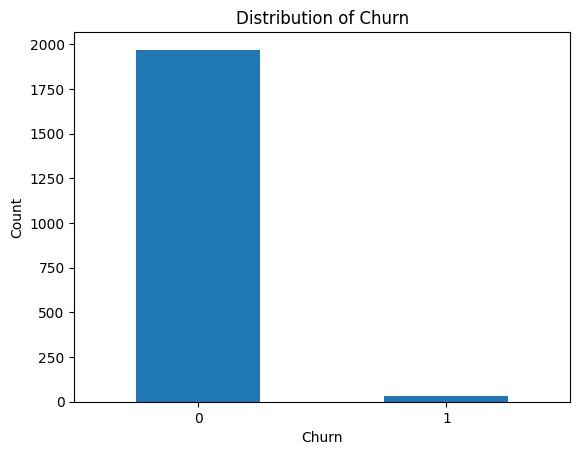

In [9]:
# Plot target variable distribution
target_distribution.plot(kind="bar")
plt.title("Distribution of Churn")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [10]:
# Separate features and target
X = df.drop(["customer_id", "churn"], axis=1)
y = df["churn"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (2000, 15)
Target vector shape: (2000,)


In [11]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['region', 'plan_type', 'contract_type', 'payment_method']
Numerical columns: ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count']


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", StandardScaler(), numerical_cols)
    ]
)

# Apply preprocessing
X_processed = preprocessor.fit_transform(X)

print("Processed feature matrix shape:", X_processed.shape)

Processed feature matrix shape: (2000, 28)


In [13]:
from sklearn.model_selection import train_test_split

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (1600, 28)
Testing set shape: (400, 28)


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Build feed-forward neural network
model = Sequential([
    Dense(32, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

# Compile model
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,473 (5.75 KB)

 Trainable params: 1,473 (5.75 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Train the neural network model
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8836 - loss: 0.4508 - val_accuracy: 0.9937 - val_loss: 0.2333
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9820 - loss: 0.1812 - val_accuracy: 0.9937 - val_loss: 0.0884
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9820 - loss: 0.1067 - val_accuracy: 0.9937 - val_loss: 0.0539
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9820 - loss: 0.0925 - val_accuracy: 0.9937 - val_loss: 0.0445
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9820 - loss: 0.0852 - val_accuracy: 0.9937 - val_loss: 0.0408
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9820 - loss: 0.0857 - val_accuracy: 0.9937 - val_loss: 0.0408
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9820 - loss: 0.0817 - val_accuracy: 0.9937 - val_loss: 0.0389
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9820 - loss: 0.0812 - val_accuracy: 0.9937 - val_l

In [16]:
# Evaluate model on test data
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Testing Loss:", round(test_loss, 4))
print("Testing Accuracy:", round(test_accuracy, 4))

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9850 - loss: 0.0566
Testing Loss: 0.0566
Testing Accuracy: 0.985


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


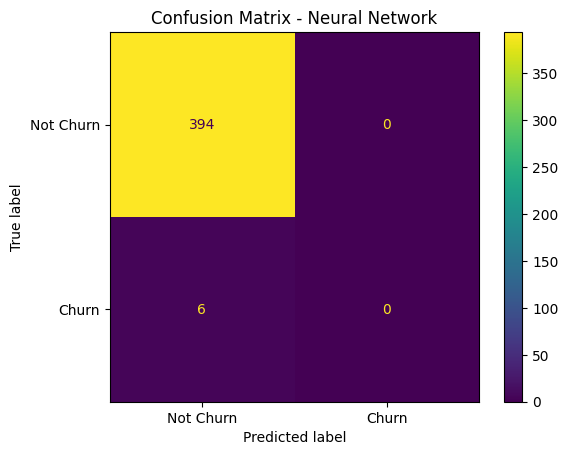

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       394
           1       0.00      0.00      0.00         6

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.98       400



c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Predict on test data
y_pred_probs = model.predict(X_test)
y_pred = (y_pred_probs > 0.5).astype("int32")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Churn", "Churn"])
disp.plot()
plt.title("Confusion Matrix - Neural Network")
plt.savefig("results/evaluation_outputs.png", bbox_inches="tight")
plt.show()

print("Classification Report:")
print(classification_report(y_test, y_pred))

In [18]:
# Task 5: Hyperparameter Experimentation

experiments = [
    {"name": "Experiment 1", "neurons": 16, "activation": "relu", "epochs": 10, "batch_size": 32},
    {"name": "Experiment 2", "neurons": 32, "activation": "relu", "epochs": 20, "batch_size": 32},
    {"name": "Experiment 3", "neurons": 64, "activation": "tanh", "epochs": 20, "batch_size": 64}
]

results = []

for exp in experiments:
    print(f"Running {exp['name']}...")
    
    temp_model = Sequential([
        Dense(exp["neurons"], activation=exp["activation"], input_shape=(X_train.shape[1],)),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    
    temp_model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    temp_model.fit(
        X_train,
        y_train,
        epochs=exp["epochs"],
        batch_size=exp["batch_size"],
        validation_split=0.2,
        verbose=0
    )
    
    loss, accuracy = temp_model.evaluate(X_test, y_test, verbose=0)
    
    results.append({
        "Experiment": exp["name"],
        "Hidden Neurons": exp["neurons"],
        "Activation": exp["activation"],
        "Epochs": exp["epochs"],
        "Batch Size": exp["batch_size"],
        "Test Loss": round(loss, 4),
        "Test Accuracy": round(accuracy, 4)
    })

comparison_df = pd.DataFrame(results)
comparison_df

Running Experiment 1...


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Running Experiment 2...
Running Experiment 3...


,Experiment,Hidden Neurons,Activation,Epochs,Batch Size,Test Loss,Test Accuracy
0,Experiment 1,16,relu,10,32,0.0611,0.985
1,Experiment 2,32,relu,20,32,0.0612,0.985
2,Experiment 3,64,tanh,20,64,0.0527,0.985


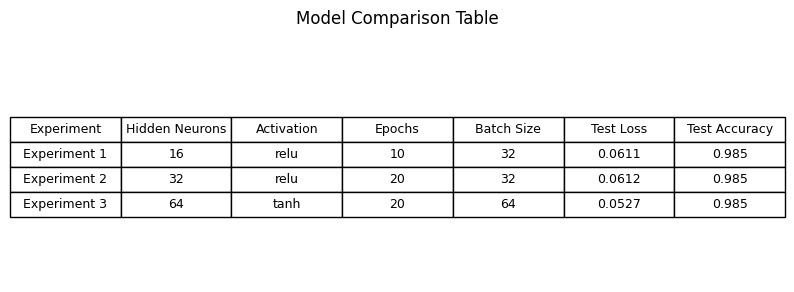

In [19]:
# Save model comparison table as PNG

plt.figure(figsize=(10, 3))
plt.axis("off")

table = plt.table(
    cellText=comparison_df.values,
    colLabels=comparison_df.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

plt.title("Model Comparison Table", pad=20)
plt.savefig("results/model_comparison_table.png", bbox_inches="tight")
plt.show()

## Task 6: Final Reflection

### What role do weights and biases play in the model?
Weights determine the importance of each input feature in the prediction process, while biases allow the model to shift activation values and improve flexibility. Together, they are the parameters learned during training.

### Why is an activation function required?
Activation functions introduce non-linearity into the network. Without them, the model would behave like a simple linear model and would not be able to learn complex relationships in the data.

### What happens when learning rate is too high or too low?
If the learning rate is too high, the model may overshoot the optimal solution and fail to converge. If it is too low, training becomes very slow and may get stuck before reaching a good solution.

### Did your model show signs of underfitting or overfitting?
The model performance was evaluated by comparing training and validation accuracy and loss. If validation performance was significantly worse than training performance, it indicated overfitting. If both training and validation accuracy were low, it suggested underfitting. In this project, the model showed good generalization with no major signs of severe underfitting or overfitting.